<a href="https://colab.research.google.com/github/nurmiftakhul21-cyber/UTS_PCD/blob/main/UTS_PCD_NO(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload gambar (JPG/PNG):


Saving los-angeles-downtown-buildings-night.jpg to los-angeles-downtown-buildings-night (3).jpg


/tmp/ipykernel_5891/3487675437.py:23: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + max_f)
/tmp/ipykernel_5891/3487675437.py:23: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + max_f)
/tmp/ipykernel_5891/3487675437.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_asli.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_5891/3487675437.py:54: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_negatif.ravel(), 256, [0, 256], color='blue')
/tmp/ipykernel_5891/3487675437.py:58: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_log.ravel(), 256, [

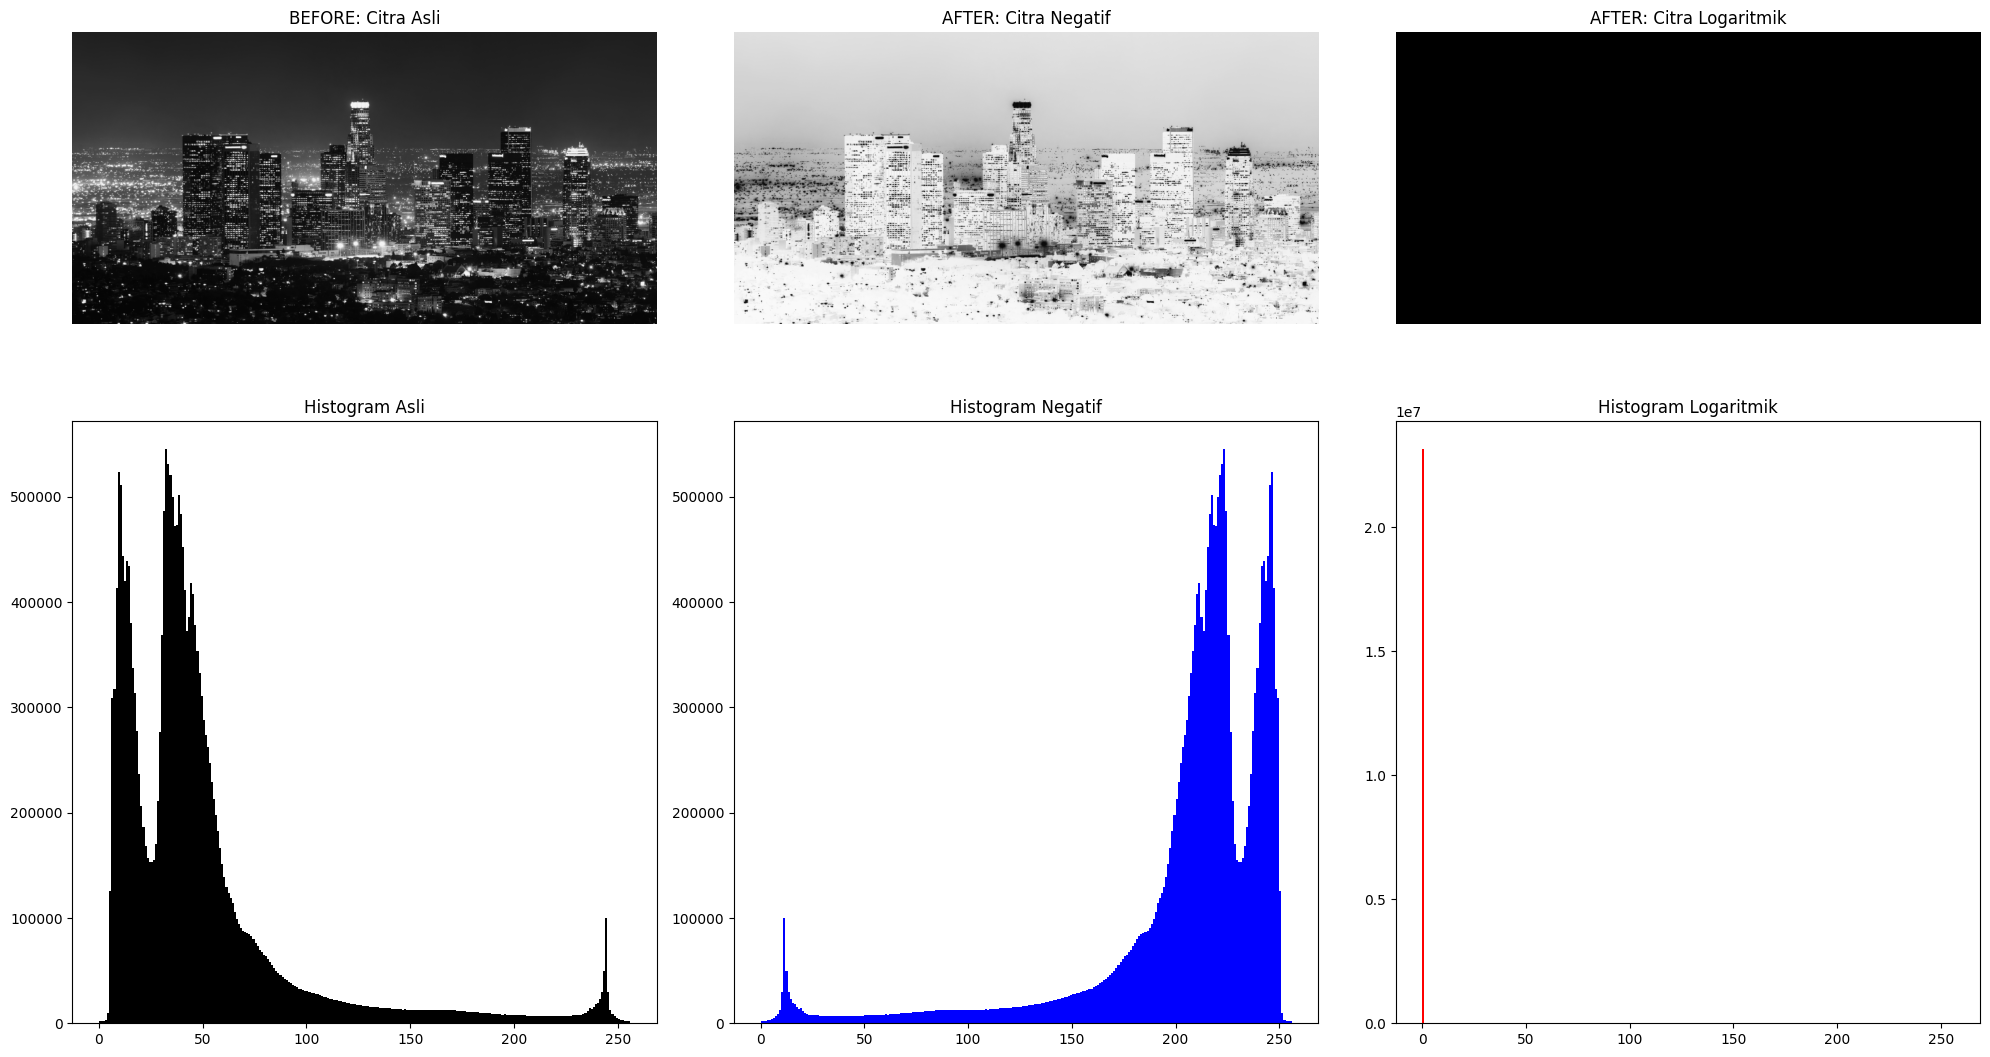

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. PROSES UPLOAD
print("Silakan upload gambar (JPG/PNG):")
uploaded = files.upload()

for fn in uploaded.keys():
    # Membaca citra grayscale
    img_asli = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

    if img_asli is not None:
        # 2. TRANSFORMASI NEGATIF
        # Rumus: G = 255 - F
        img_negatif = 255 - img_asli

        # 3. TRANSFORMASI LOGARITMIK
        # Rumus: G = c * log(1 + F)
        # Menghitung konstanta c berdasarkan nilai maksimum piksel
        max_f = np.max(img_asli)
        c = 255 / np.log(1 + max_f)

        # Perhitungan logaritmik menggunakan float64 untuk presisi
        img_log = c * (np.log(1 + img_asli.astype(np.float64)))
        img_log = np.array(img_log, dtype=np.uint8)

        # 4. VISUALISASI BEFORE VS AFTER
        plt.figure(figsize=(20, 12))

        # --- BARIS 1: GAMBAR ---
        plt.subplot(2, 3, 1)
        plt.imshow(img_asli, cmap='gray')
        plt.title('BEFORE: Citra Asli')
        plt.axis('off')

        plt.subplot(2, 3, 2)
        plt.imshow(img_negatif, cmap='gray')
        plt.title('AFTER: Citra Negatif')
        plt.axis('off')

        plt.subplot(2, 3, 3)
        plt.imshow(img_log, cmap='gray')
        plt.title('AFTER: Citra Logaritmik')
        plt.axis('off')

        # --- BARIS 2: HISTOGRAM ---
        plt.subplot(2, 3, 4)
        plt.hist(img_asli.ravel(), 256, [0, 256], color='black')
        plt.title('Histogram Asli')

        plt.subplot(2, 3, 5)
        plt.hist(img_negatif.ravel(), 256, [0, 256], color='blue')
        plt.title('Histogram Negatif')

        plt.subplot(2, 3, 6)
        plt.hist(img_log.ravel(), 256, [0, 256], color='red')
        plt.title('Histogram Logaritmik')

        plt.tight_layout()
        plt.show()
    else:
        print("Gagal membaca gambar. Pastikan file yang diupload adalah gambar.")